In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


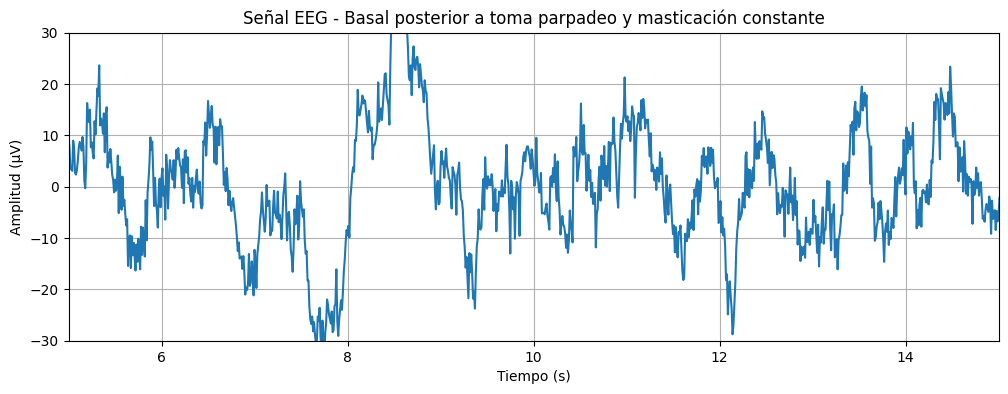

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Ruta del archivo
ruta = "/content/drive/MyDrive/vallejo/EEG_signals/Musicaestresante6.txt" #Nombre de archivo

# Leer datos ignorando encabezados con #
data = np.loadtxt(ruta)

# Extraer canal EEG (A4)
eeg_adc = data[:, 5]

# Parámetros BITalino EEG
n = 10          # resolución ADC
VCC = 3.3       # voltaje alimentación
G = 40000       # ganancia EEG BITalino

# Remover offset DC (~512)
eeg_centered = eeg_adc - np.mean(eeg_adc)

# Conversión a microvoltios
eeg_uV = (eeg_centered / (2**n)) * (VCC / G) * 1e6

# Frecuencia de muestreo
fs = 100
t = np.arange(len(eeg_uV)) / fs


# Plot
plt.figure(figsize=(12,4))
plt.plot(t, eeg_uV)
plt.title("Señal EEG - Basal posterior a toma parpadeo y masticación constante")
plt.xlabel("Tiempo (s)")
plt.ylabel("Amplitud (µV)")
plt.xlim(5, 15)
plt.ylim(-30, 30)
plt.grid(True)

plt.show()

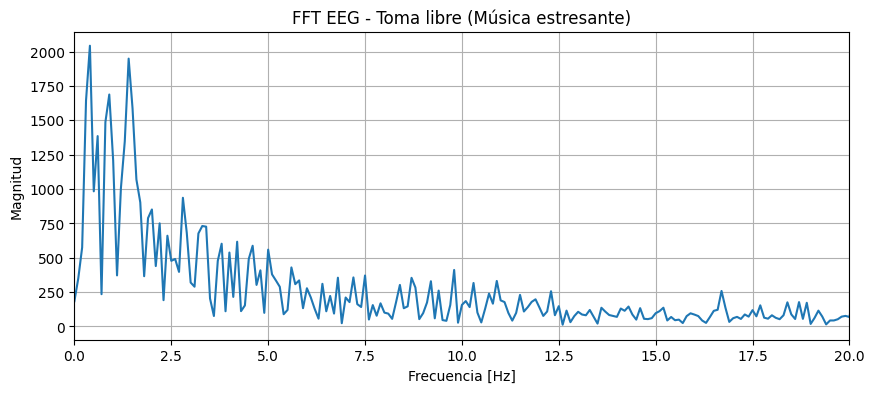

In [ ]:
# Segmentos elegidos (segundos)
inicio = 20
fin = 30

# -------
idx_inicio = int(inicio * fs)
idx_fin = int(fin * fs)

segmento = eeg_uV[idx_inicio:idx_fin]

# FFT
N = len(segmento)

fft_vals = np.fft.fft(segmento)

# Frecuencias
freqs = np.fft.fftfreq(N, d=1/fs)
magnitud = np.abs(fft_vals)
mask = freqs >= 0
freqs_pos = freqs[mask]
magnitud_pos = magnitud[mask]

# Plot
plt.figure(figsize=(10,4))
plt.plot(freqs_pos, magnitud_pos)
plt.title("FFT EEG - Toma libre (Música estresante)")
plt.xlabel("Frecuencia [Hz]")
plt.ylabel("Magnitud")
plt.xlim(0, 20)
plt.grid(True)
plt.show()